In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#load dataset

train_data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

print("Data loaded successfully")



Data loaded successfully


In [3]:
df=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df.fillna(0,inplace=True)

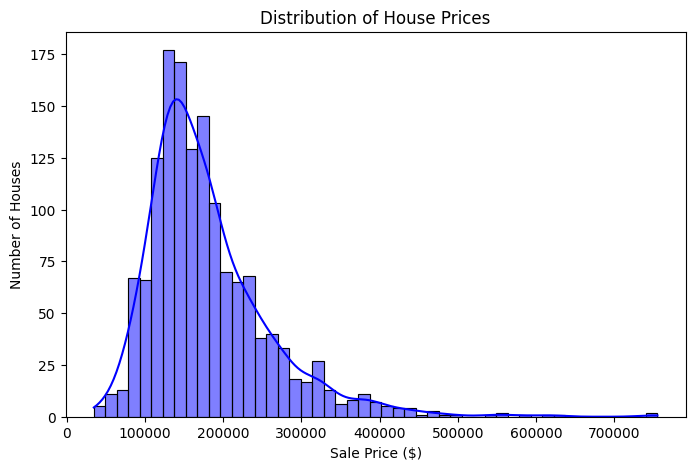

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(train_data['SalePrice'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.show()


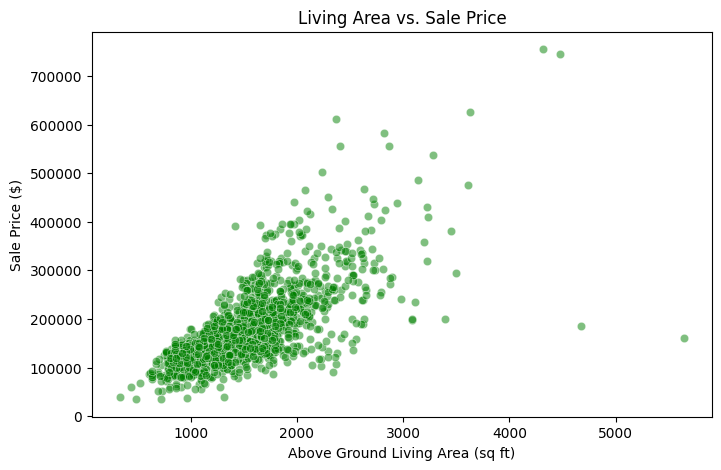

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train_data['GrLivArea'], y=train_data['SalePrice'], alpha=0.5, color='green')
plt.title('Living Area vs. Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

In [9]:
# Select a few simple features
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']

# X is what we use to predict (the features)
X = train_data[features]

# We need to fill in any missing data (blanks). For simplicity, we'll fill blanks with 0
X = X.fillna(0)

# y is what we want to predict (the target)
y = train_data['SalePrice']

# Split our training data into two parts: 80% to train the model, 20% to test it ourselves
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [10]:
# Create the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model (this is where the machine learns)
model.fit(X_train, y_train)

# Ask the model to predict prices for the 20% of data we hid from it
predictions = model.predict(X_valid)

# Calculate our error (how far off are we on average?)
error = mean_absolute_error(y_valid, predictions)
print(f"On average, our model's predictions are off by: ${error:,.0f}")

On average, our model's predictions are off by: $19,181


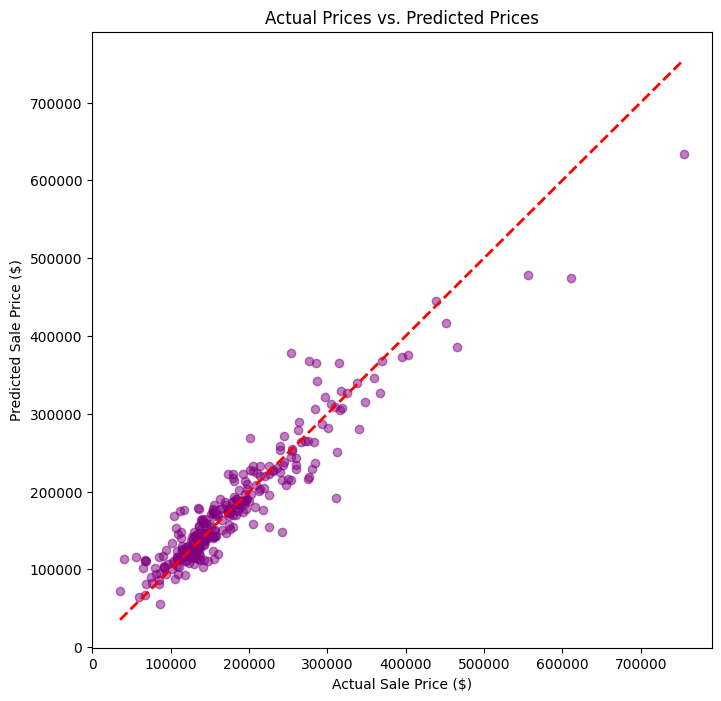

In [11]:
plt.figure(figsize=(8, 8))
plt.scatter(y_valid, predictions, alpha=0.5, color='purple')

# Draw a perfect prediction line for reference
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)

plt.title('Actual Prices vs. Predicted Prices')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.show()

In [12]:
# 1. Grab the same features from the test data and fill missing values
X_test = test_data[features].fillna(0)

# 2. Make predictions on the test data
final_predictions = model.predict(X_test)

# 3. Create a dataframe in the exact format Kaggle asks for
output = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': final_predictions
})

# 4. Save it as a CSV file without the index column
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [13]:
# 1. Grab all features (drop the ID and the SalePrice from our training data)
X_all = train_data.drop(['Id', 'SalePrice'], axis=1)

# 2. Split into Numbers and Text so we can clean them differently
# Grab only columns with numbers and fill blanks with 0
X_numeric = X_all.select_dtypes(exclude=['object']).fillna(0)

# Grab only columns with text ('object') and fill blanks with the word "None"
X_categorical = X_all.select_dtypes(include=['object']).fillna("None")

# 3. Combine them back together
X_cleaned = pd.concat([X_numeric, X_categorical], axis=1)

# 4. THE MAGIC TRICK: Translate all text into numbers!
X_encoded = pd.get_dummies(X_cleaned)

print(f"We started with {X_all.shape[1]} columns.")
print(f"After translating text to numbers, we now have {X_encoded.shape[1]} columns!")

We started with 79 columns.
After translating text to numbers, we now have 303 columns!
